### Imports

In [ ]:
import sys
sys.path.remove('/user/home/ef17148/.local/lib/python3.12/site-packages')

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr

import sys
sys.path.insert(0, "..")

from model.data.load_data import LoadBaseSatelliteData

In [2]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [23]:
from vis_plotting.fp_plotting import *
from vis_plotting.general_plotting import *
from vis_plotting.topog_plotting import *

### Data loading

In [54]:
"""
Load the footprints for the region and period with the base data object.
Stores the footprints (without cropping) in data.fp_data_full
load_everything=True also loads the original meteorology, without cropping or interpolating, in data.met_file, as well as the topography and landuse in data.topog_file and data.landcover_file, which are interpolated in space to the shape of the footprints
"""
data = LoadBaseSatelliteData(2016, region="BRAZIL", load_everything=True, verbose=True)

---- LOADING FOOTPRINTS
Loading footprint data from /group/chem/acrg/LPDM/fp_NAME_pre20210701/SOUTHAMERICA/*BRAZIL*SOUTHAMERICA_2016*.nc
no sampling was done because you didnt pass a valid sampling mode, or freq=1
Loading 21671 footprints

 ---- LOADING MET
Loading meteorology from /group/chem/acrg/met_archive/UM/SOUTHAMERICA/SOUTHAMERICA_Met_2016*.nc

---- LOADING TOPOG
trying to load topography from /group/chem/acrg/LPDM/topog_NAME/TopogUMG_Mk8_global.nc
---- All done!


### New: loading country masks

In [55]:
data.align_met_domain()
data.get_country_masks()
# Use this to obtain a mask for a specific country
#brazil_mask = data.countries.country_mask.sel(name="BRAZIL")

# use this to plot the country masks
#data.countries.country.plot(levels=len(data.countries.name), cmap='tab20c', add_colorbar=False)

trying to load country mask from /group/chem/acrg/LPDM/countries/country_SOUTHAMERICA.nc
country mask loaded successfully at self.countries.country_mask and landmask at self.countries.land_mask


## Plotting meteorology

In [56]:
data.met_file

<xarray.Dataset>
Dimensions:                              (levels: 20, time: 8760, lat: 357,
                                          lon: 190)
Coordinates:
    sigma                                (levels) float32 dask.array<chunksize=(20,), meta=np.ndarray>
  * levels                               (levels) int32 1 3 6 9 ... 48 51 54 57
    level_height                         (levels) float32 dask.array<chunksize=(20,), meta=np.ndarray>
  * time                                 (time) datetime64[ns] 2016-01-01 ......
  * lat                                  (lat) float32 -60.98 -60.75 ... 22.32
  * lon                                  (lon) float32 -91.33 -90.98 ... -24.8
Data variables:
    air_pressure                         (levels, lat, lon, time) float32 dask.array<chunksize=(20, 357, 190, 744), meta=np.ndarray>
    air_pressure_at_sea_level            (lat, lon, time) float32 dask.array<chunksize=(357, 190, 744), meta=np.ndarray>
    air_temperature                      (levels, lat, lon, time) float32 dask.array<chunksize=(20, 357, 190, 744), meta=np.ndarray>
    atmosphere_boundary_layer_thickness  (lat, lon, time) float32 dask.array<chunksize=(357, 190, 744), meta=np.ndarray>
    surface_air_pressure                 (lat, lon, time) float32 dask.array<chunksize=(357, 190, 744), meta=np.ndarray>
    surface_upward_sensible_heat_flux    (lat, lon, time) float32 dask.array<chunksize=(357, 190, 744), meta=np.ndarray>
    upward_air_velocity                  (levels, lat, lon, time) float32 dask.array<chunksize=(20, 357, 190, 744), meta=np.ndarray>
    x_wind                               (levels, lat, lon, time) float32 dask.array<chunksize=(20, 357, 190, 744), meta=np.ndarray>
    y_wind                               (levels, lat, lon, time) float32 dask.array<chunksize=(20, 357, 190, 744), meta=np.ndarray>
Attributes:
    source:           Data from Met Office Unified Model
    author:           Elena Fillola (ef17148)
    created:          2022-11-14 13:11
    transformations:  interpolated linearly in space to NAME resolution, inte...

## Plotting footprints

In [57]:
data.fp_data_full

<xarray.Dataset>
Dimensions:               (time: 21671, lon: 190, lat: 357, lev: 1, height: 20)
Coordinates:
  * time                  (time) datetime64[ns] 2016-01-01T14:59:12.500000 .....
  * lon                   (lon) float32 -91.33 -90.98 -90.62 ... -25.15 -24.8
  * lat                   (lat) float32 -60.98 -60.75 -60.51 ... 22.09 22.32
  * lev                   (lev) |S1 b'c'
  * height                (height) float32 500.0 1.5e+03 ... 1.85e+04 1.95e+04
Data variables:
    fp                    (lat, lon, time) float32 dask.array<chunksize=(357, 190, 1438), meta=np.ndarray>
    temperature           (time) float32 dask.array<chunksize=(1438,), meta=np.ndarray>
    pressure              (time) float32 dask.array<chunksize=(1438,), meta=np.ndarray>
    wind_speed            (time) float32 dask.array<chunksize=(1438,), meta=np.ndarray>
    wind_direction        (time) float32 dask.array<chunksize=(1438,), meta=np.ndarray>
    PBLH                  (time) float32 dask.array<chunksize=(1438,), meta=np.ndarray>
    release_lon           (time) float32 dask.array<chunksize=(1438,), meta=np.ndarray>
    release_lat           (time) float32 dask.array<chunksize=(1438,), meta=np.ndarray>
    particle_locations_n  (height, lon, time) float32 dask.array<chunksize=(20, 190, 1438), meta=np.ndarray>
    particle_locations_e  (height, lat, time) float32 dask.array<chunksize=(20, 357, 1438), meta=np.ndarray>
    particle_locations_s  (height, lon, time) float32 dask.array<chunksize=(20, 190, 1438), meta=np.ndarray>
    particle_locations_w  (height, lat, time) float32 dask.array<chunksize=(20, 357, 1438), meta=np.ndarray>
Attributes:
    max_level:  17
    author:     rt17603
    created:    2019-05-29 20:05:49.874413

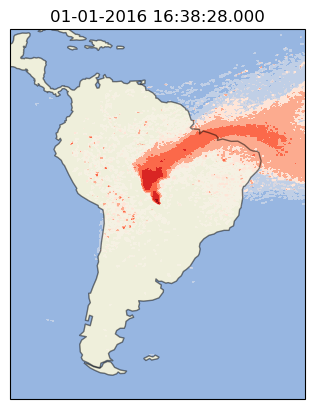

In [58]:
data.plot_footprint(idx=10)

0 JFM  - n values: 4459
1 AMJ  - n values: 5241


/user/home/kr21883/miniconda3/envs/new_graphnet/lib/python3.12/site-packages/xarray/core/indexing.py:1443: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]


2 JAS  - n values: 7400
3 OND  - n values: 4571


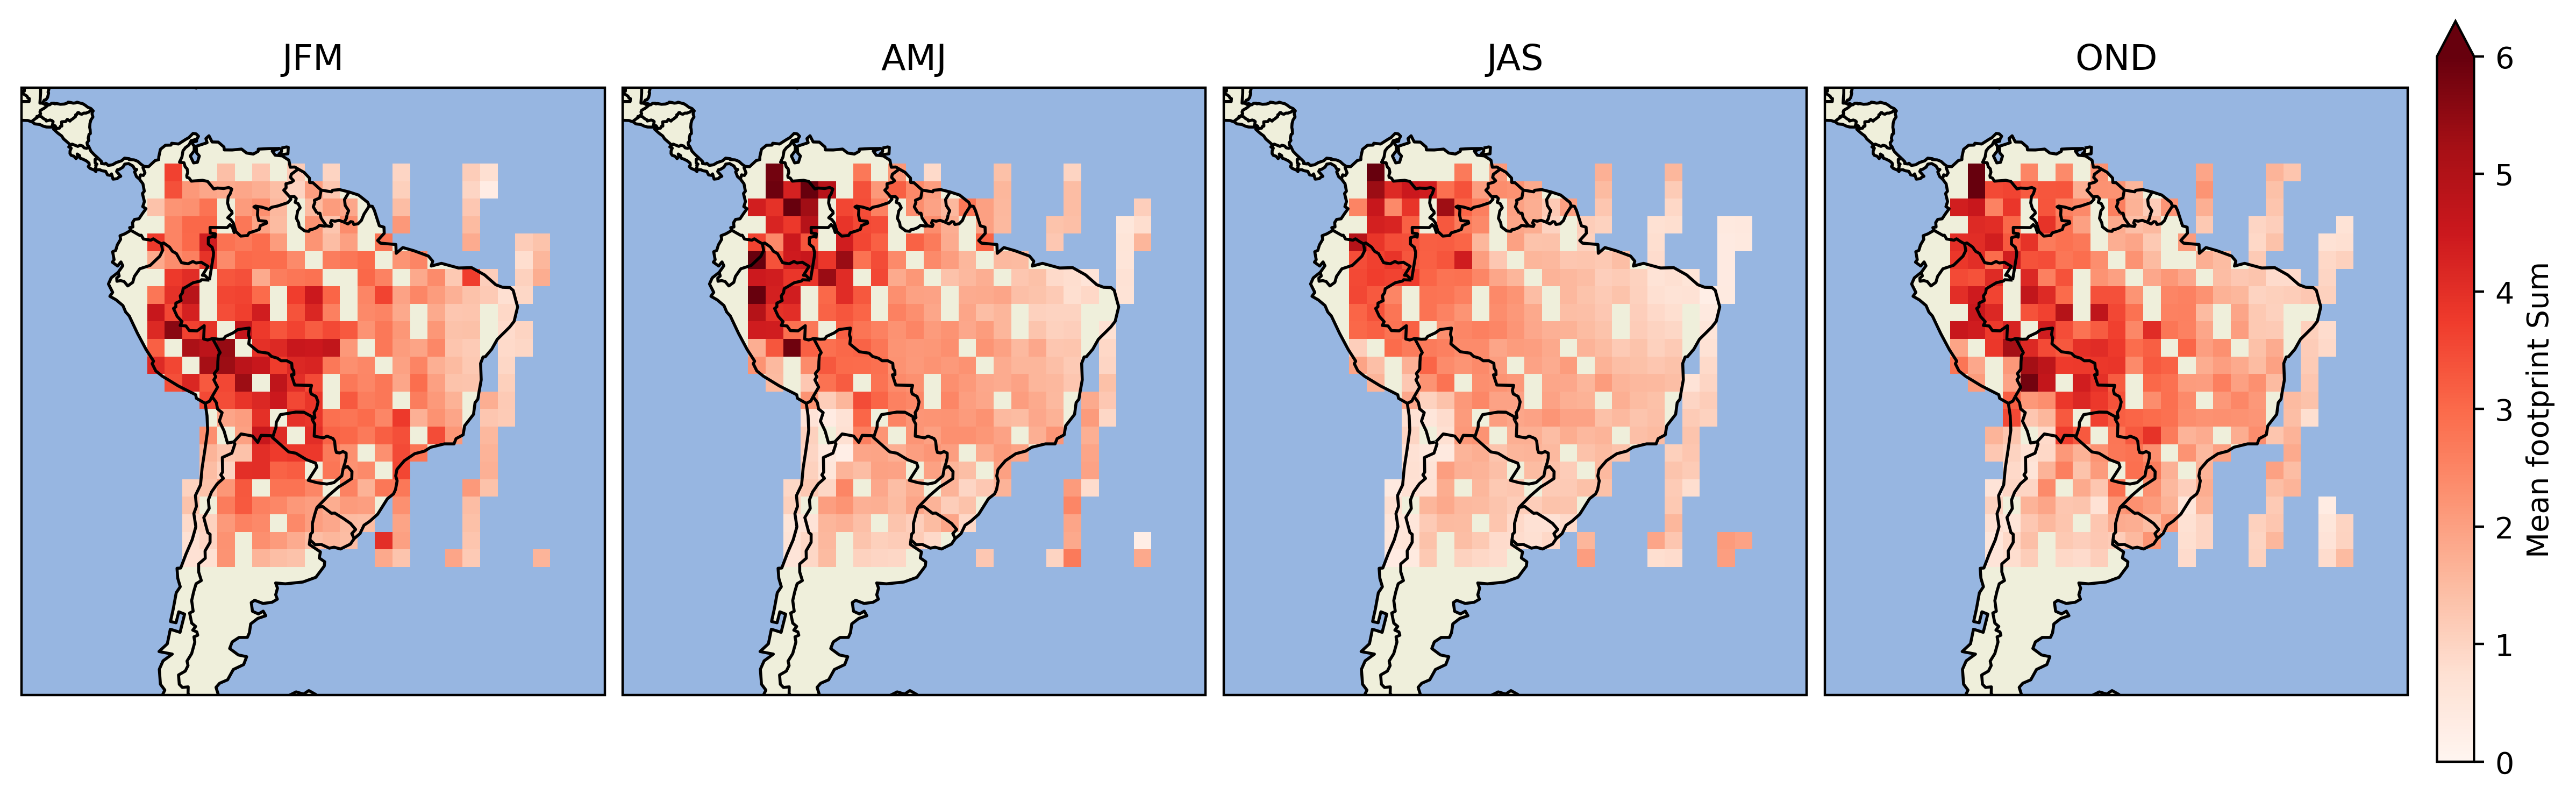

In [59]:
# plot the mean sum of the footprint binned by the measurement location in 2-degree bins

plot_seasonal_footprint_histogram(data.fp_data_full, metric="mean_sum", degree_bins=2, vmin_vmax=[0,6], return_fig=False)

0 JFM  - n values: 4459
1 AMJ  - n values: 5241
2 JAS  - n values: 7400
3 OND  - n values: 4571


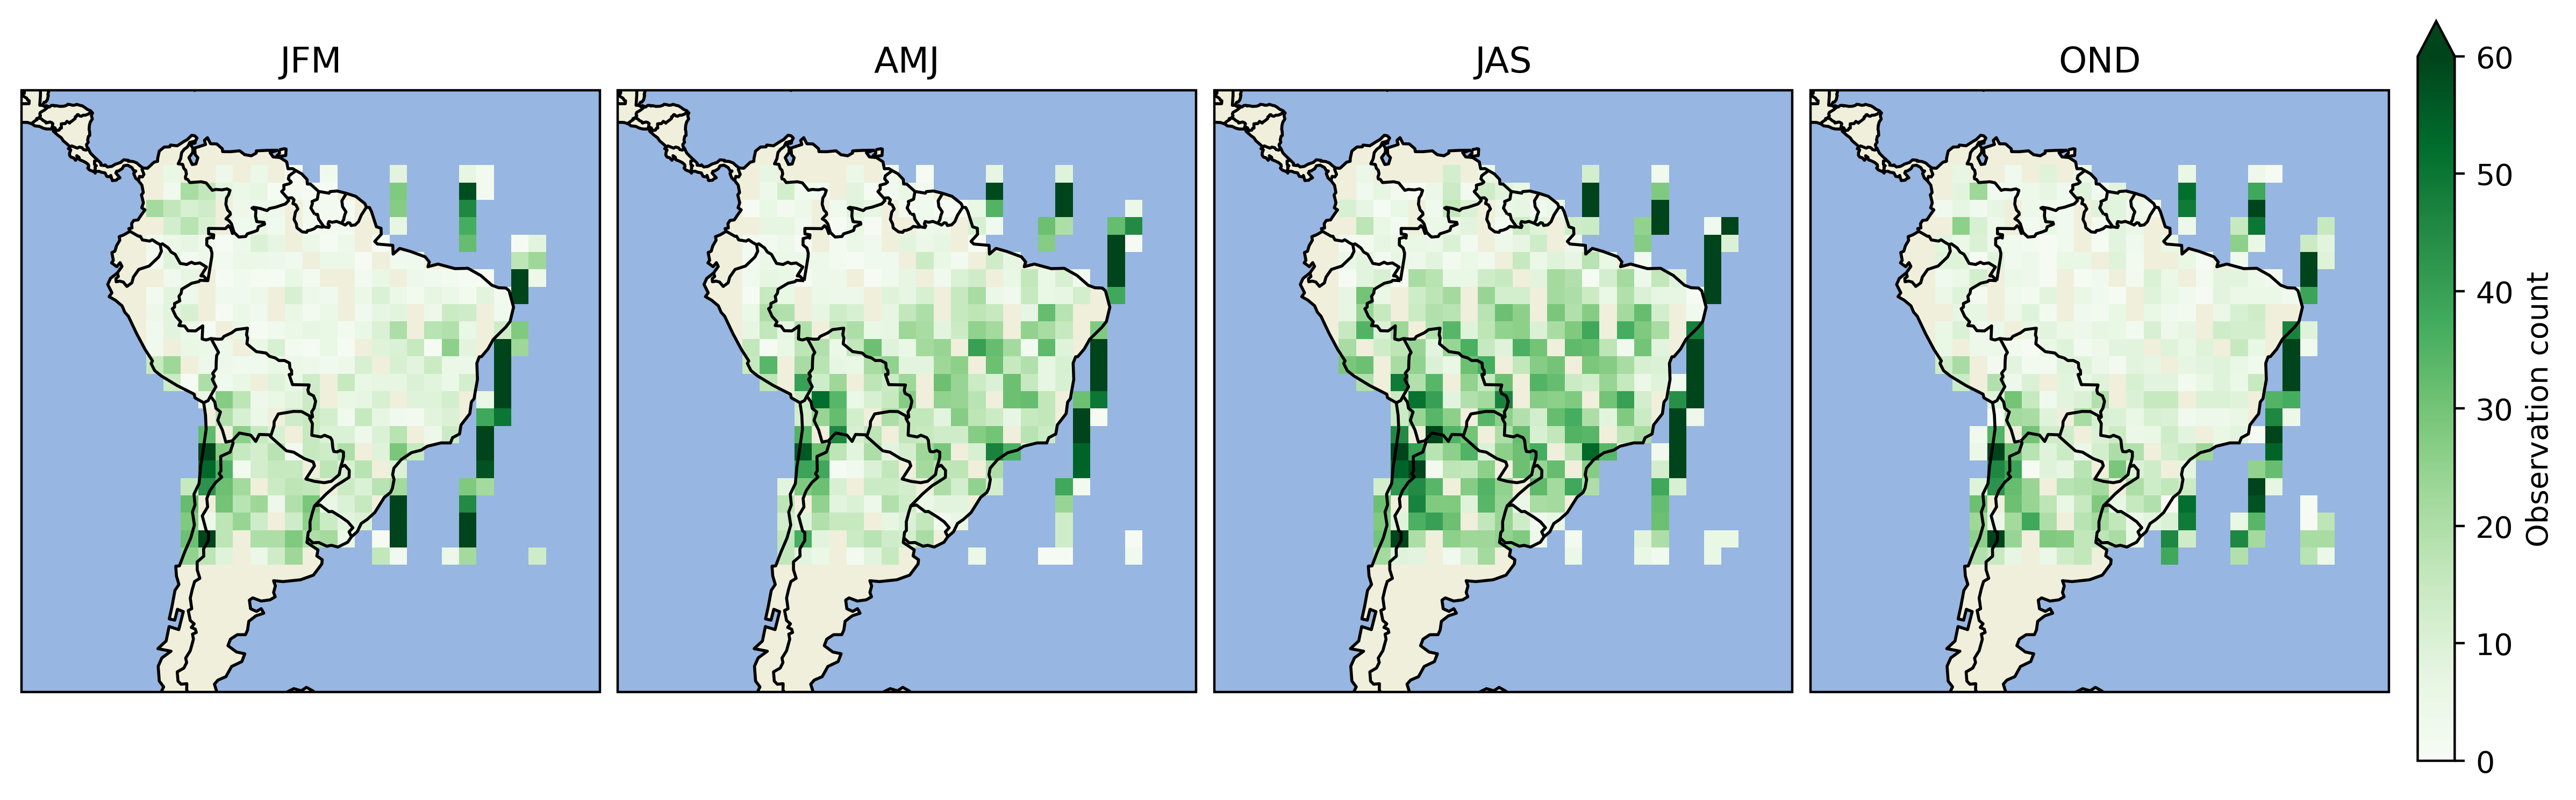

In [60]:
# plot the count of the footprint binned by the measurement location in 2-degree bins

plot_seasonal_footprint_histogram(data.fp_data_full, metric="count", degree_bins=2, vmin_vmax=[0,60], return_fig=False)

## Plotting topography and land use

In [61]:
data.topog_file

<xarray.Dataset>
Dimensions:             (lat: 357, lon: 190)
Coordinates:
  * lat                 (lat) float32 -60.98 -60.75 -60.51 ... 21.85 22.09 22.32
  * lon                 (lon) float32 -91.33 -90.98 -90.62 ... -25.15 -24.8
Data variables:
    surface_altitude    (lat, lon) float32 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    latitude_longitude  int32 -2147483647
Attributes:
    source:       Data from Met Office Unified Model
    um_version:   8.3
    Conventions:  CF-1.7

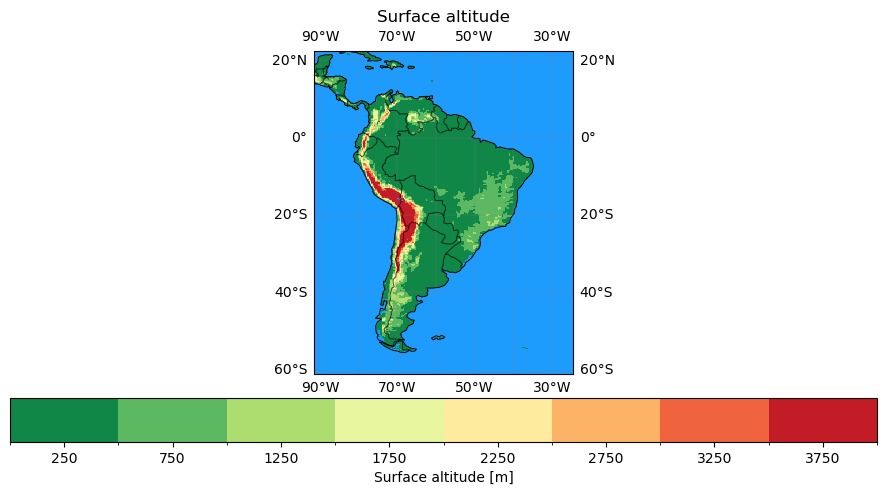

In [62]:
fig, ax, mesh, edges = plot_topography(
    data,
    n_bins=8,
    vmin=0, vmax=4000, # Max altitude in metres
    plot_country_boundaries=True
)

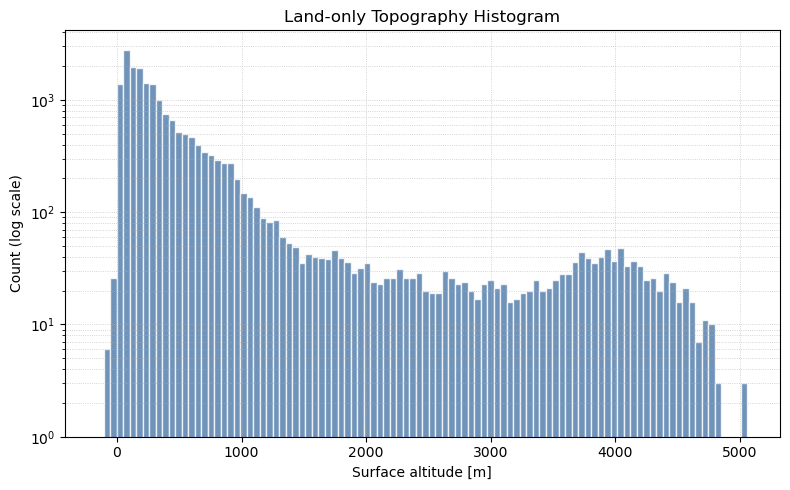

In [63]:
# And a histogram of the topography values (land-only, excluding ocean pixels which are at 0m but not land)
fig, ax, _ = plot_topography_histogram(
    data,
    bins=100,
    log_y=True,
    density=False,
    title="Land-only Topography Histogram"
)

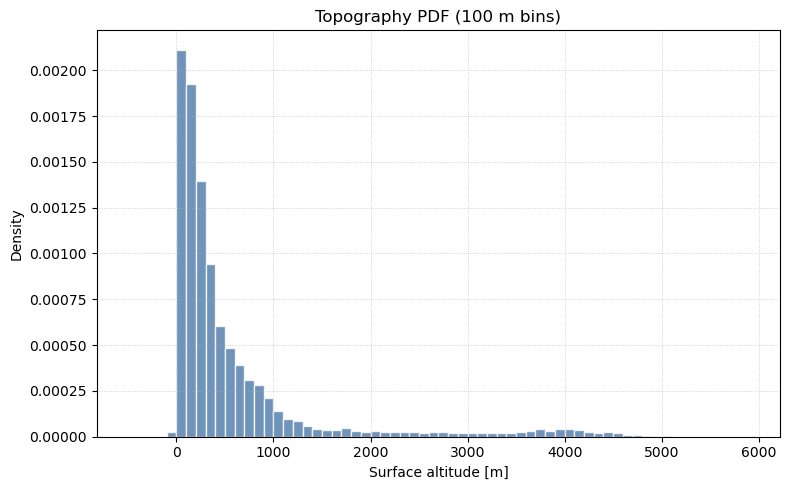

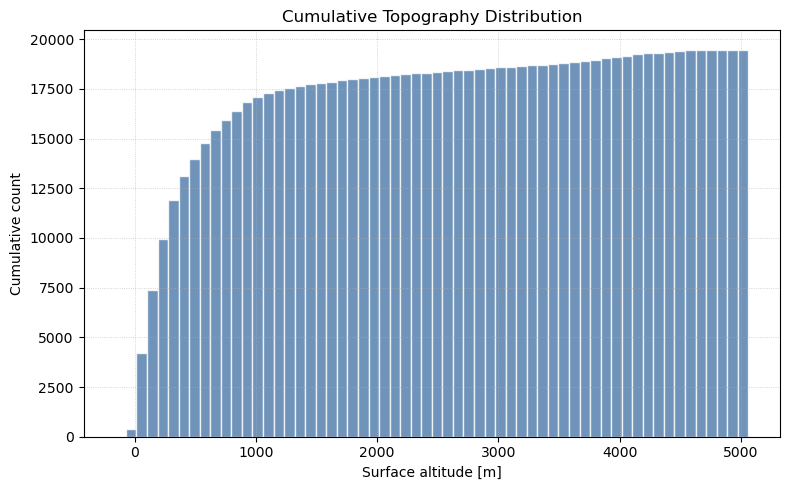

In [64]:
# Two more examples: 
# Probability density function
fig, ax, _ = plot_topography_histogram(
    data,
    bins=np.arange(-500, 6000, 100),
    density=True,
    title="Topography PDF (100 m bins)"
)

# Cumulative distribution function
fig, ax, _ = plot_topography_histogram(
    data,
    bins=60,
    cumulative=True,
    title="Cumulative Topography Distribution"
)

### Land use

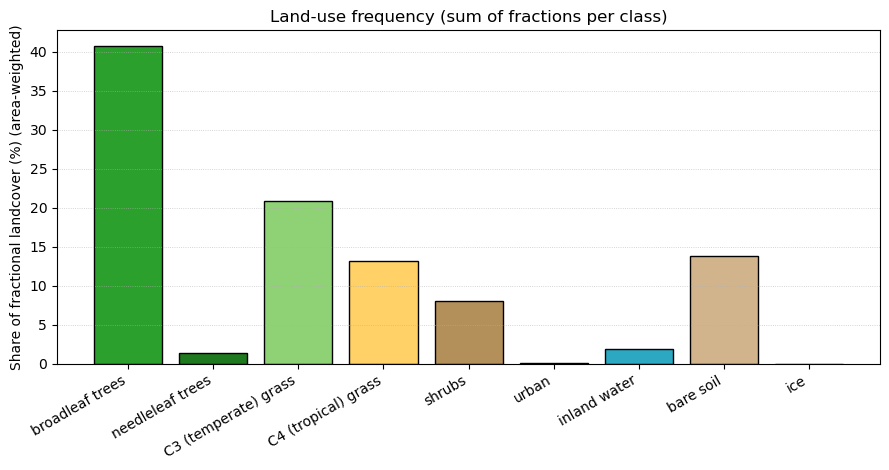

In [65]:
fig, ax, freq = plot_landuse_frequency(
    data,
    area_weighted=True,
)


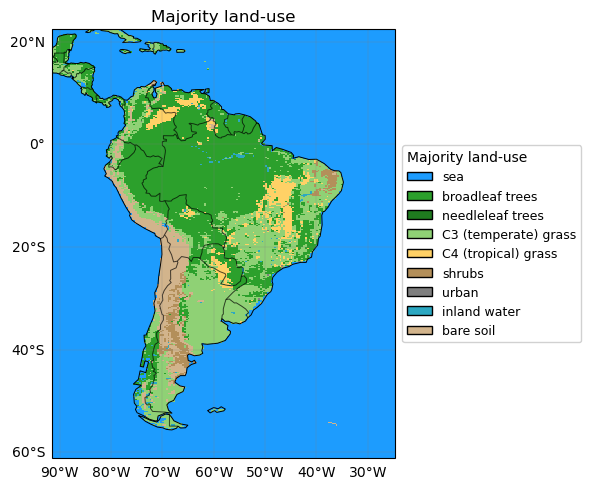

In [66]:
fig, ax, mesh, majority, (cmap, norm) = plot_majority_landuse_map(
    data,
    title="Majority land‑use"
)

## Spatial data availability

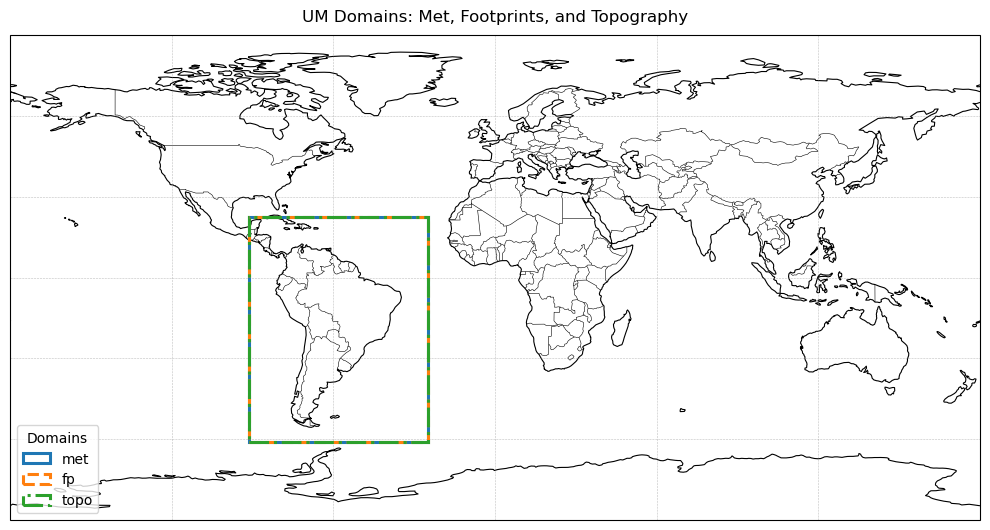

In [67]:
# Plot all three series' with distinct styles
fig, ax = plot_multiple_data_series(
    data,
    show=("met", "fp", "topo"),
    colours={"met":"tab:blue", "fp":"tab:orange", "topo":"tab:green"},
    linestyles={"met":"-", "fp":"--", "topo":"-."},
    linewidths={"met":2.2, "fp":2.2, "topo":2.2},
    facealpha=0.0,                 # set to, e.g., 0.15 if you want light fills
    projection="PlateCarree",
    wrap_center=0,
    zoom_to_union=False,
    title="UM Domains: Met, Footprints, and Topography"
)
plt.show()

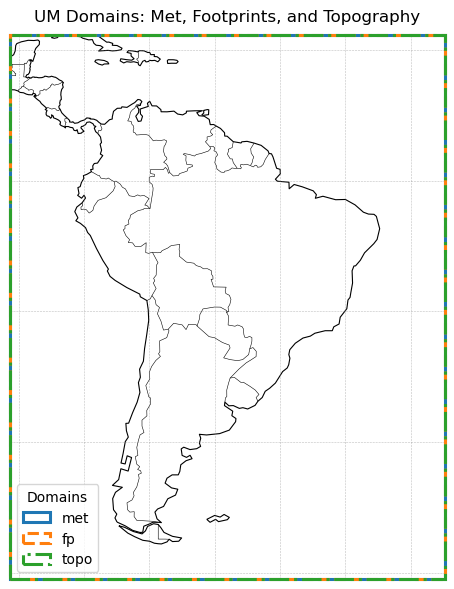

In [68]:
# Plot all three, zooming to the union of their extents
fig, ax = plot_multiple_data_series(
    data,
    show=("met", "fp", "topo"),
    colours={"met":"tab:blue", "fp":"tab:orange", "topo":"tab:green"},
    linestyles={"met":"-", "fp":"--", "topo":"-."},
    linewidths={"met":2.2, "fp":2.2, "topo":2.2},
    facealpha=0.0,                 # set to, e.g., 0.15 if you want light fills
    projection="PlateCarree",
    wrap_center=0,
    zoom_to_union=True,
    title="UM Domains: Met, Footprints, and Topography"
)
plt.show()